In [1]:
import pickle
import re 
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import os
# import joypy

import scipy.stats as sstat
ZZ = sstat.norm.ppf

import mz_Lick_functions as mz_Lick

%matplotlib inline
%load_ext autoreload
%autoreload 2
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif']  

sns.despine()

<Figure size 640x480 with 0 Axes>

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
        'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
        'axes.linewidth':2.5, 'lines.linewidth': 2.5,
        'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black',
        'axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

set_pub_plots()

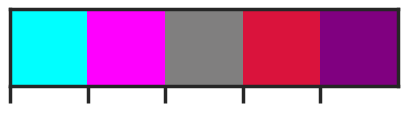

In [3]:
pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)
sns.palplot(pal)
sns.set_palette(pal)

---

# Define universal variables first

In [4]:
# u = start of trial
# m = no licks
# r = timestamp of reward
# z = rew2 stimulus
# o = unrew stimulus
# r, z, and o happen after the delay after the stimulus ends (1-sec or 2-sec)

interval = 1.0 # 1 second or 2 seconds depending on the training stage
stim_dur = 0.2
inter_dur = interval+stim_dur

rewarded_trials = 90
unrew_trials = 50
rew_trials = 80
rew2_trials = 20

In [5]:
#Psuedo random presentation of the stimuli - 25 per row * 6 rows = 150 trials
# 0 -- drifting grating, rewarded stimulus, 100 trials
# 1 -- pink noise, unrewarded stimulus, 50 trials
stim_order = [0,1,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,
               0,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,1,0,0,0,0,1,
               0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,1,0,0,0,0,1,
               0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,
               1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,1,0,0,
               0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0]

#Psuedo random distribution of water to the rewarded stimuli
# 0 -- water given -- 80 times
# 1 -- no water given -- 20 times
rew_order = [0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,
               0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,
               0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,
               0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0]

overall_order = []
i=0
for idx,val in enumerate(stim_order):
    if val == 0:
        i = i+1
        if rew_order[i-1] == 0:
            overall_order.append('0') # rewH20
        elif rew_order[i-1] == 1:
            overall_order.append('1') # rewnoH20
    elif val == 1:
        overall_order.append('2')     # unrew
print(len(overall_order))

150


In [7]:
overall_order[0:10]

['0', '2', '2', '0', '0', '2', '0', '0', '2', '1']

---

# Single mouse, single training day

In [88]:
# Start of Training
# WT mouse
# single_path = r"C:\Users\AChub_Lab\Desktop\lick_days\07.08.21\CC084621_HP1_oper_disc_2021-07-08_11-30-50.pkl"
# FX mouse
# single_path = r"C:\Users\AChub_Lab\Desktop\lick_days\07.08.21\CC067431_HP1_oper_disc_2021-07-08_13-16-44.pkl"


# End of Training
# WT mouse
single_path = r"U:\Data\zimmer94\Behavior\licks\08.04.21\CC082263_HP2_oper_disc_2021-08-04_14-27-45.pkl"
# FX mouse
# single_path = r"C:\Users\AChub_Lab\Desktop\lick_days\08.04.21\CC067432_HP1_oper_disc_2021-08-04_16-40-48.pkl"

In [89]:
f=open(single_path, 'rb')
objs = []
while 1:
    try:
        objs.append(pickle.load(f))
    except EOFError:
        break
f.close()

rew_time_ls, rew2_time_ls, unrew_time_ls = mz_Lick.new_fun_1(objs, overall_order)
df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr = mz_Lick.new_fun_2(objs, overall_order,
                                                                               rew_time_ls, rew2_time_ls, unrew_time_ls,
                                                                               inter_dur)
df_licks2 = mz_Lick.new_fun_3(df_licks, df_licks2, num_rew_tr, num_rew2_tr, num_unrew_tr)
# df_licks2.head()

results = df_licks2.groupby('stim_id')['trial'].nunique()
num_tr_rew_rew2 = results['rew'] + results['rew2']
num_tr_rew2 = results['rew2']
num_tr_unrew = results['unrew']

Hits_rate = num_tr_rew_rew2/rewarded_trials
FA_rate = num_tr_unrew/unrew_trials
# this keeps the ZZ() values from being +inf or -inf
if Hits_rate >= 1:
    Hits_rate = 0.99999
if FA_rate >= 1:
    FA_rate = 0.99999
Training_Score = ZZ(Hits_rate) - ZZ(FA_rate)
print(Training_Score)

2.5142047226716713


In [8]:
# if perfect, the training score is ------ +8 (+inf) ----- 100 hits, 0 FA
# if awful, the training score is -------- -8 (-inf) ----- 0 hits, 50 FA
# if even, the training score is ---------     0     ----- 50 hits, 25 FA
# always lick, the training score is -----   (nan)   ----- 100 hits, 50 FA

---

# raster plot of mouse licks

In [9]:
x_plt1 = df_licks2[df_licks2['stim_id']=='rew'].lick_time.values
y_plt1 = df_licks2[df_licks2['stim_id']=='rew'].trial
title1 = 'rew'

x_plt2 = df_licks2[df_licks2['stim_id']=='rew2'].lick_time.values
y_plt2 = df_licks2[df_licks2['stim_id']=='rew2'].trial
title2 = 'rew2'

x_plt3 = df_licks2[df_licks2['stim_id']=='unrew'].lick_time.values
y_plt3 = df_licks2[df_licks2['stim_id']=='unrew'].trial
title3 = 'unrew'

In [10]:
cc = single_path.split('\\')[-1].split('_')[0]

if (cc == "CC082263") | (cc == "CC067489") | (cc == "CC082260") | (cc == "CC084621"):
    mouse_type = 'WT'
    plt_color = 'blue'
elif (cc == "CC082257") | (cc == "CC067431") | (cc == "CC067432") | (cc == "CC082255"):
    mouse_type = 'FX'
    plt_color = 'purple'
else:
    raise ValueError('Incorrect path, check the code...')

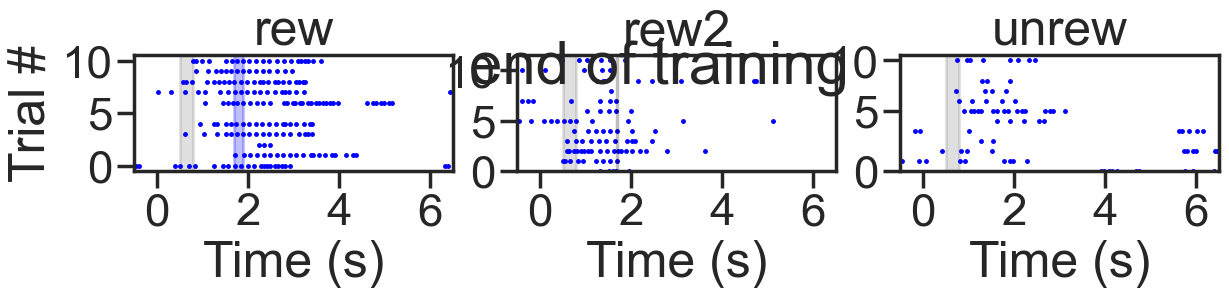

In [11]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 14.0 # x dimension
fig_size[1] = 1.5 # y dimension
plt.suptitle('end of training')

ax1 = plt.subplot(131)
plt.plot(x_plt1, y_plt1, '.', markersize=5, color=plt_color)
plt.xticks([0,2,4,6])
plt.xlim([-0.5,6.5])
plt.ylim([3.5,14.5])
plt.yticks(ticks=[4,9,14], labels=[0,5,10])
plt.axvspan(0.5,0.8, color='grey', alpha=0.25)
plt.axvspan(1.7,1.9, color='blue', alpha=0.25)
plt.title(title1)
plt.xlabel('Time (s)')
plt.ylabel('Trial #')

ax2 = plt.subplot(132, sharex=ax1)
plt.plot(x_plt2, y_plt2, '.', markersize=5, color=plt_color)
plt.ylim([84.5,95.5])
plt.yticks(ticks=[84,89,94], labels=[0,5,10])
plt.axvspan(0.5,0.8, color='grey', alpha=0.25)
plt.axvline(1.7, color='black', alpha=0.25)
plt.title(title2)
plt.xlabel('Time (s)')

ax3 = plt.subplot(133, sharex=ax1)
plt.plot(x_plt3, y_plt3, '.', markersize=5, color=plt_color)
plt.ylim([101.5,112.5])
plt.yticks(ticks=[101,107,112], labels=[0,5,10])
plt.axvspan(0.5,0.8, color='grey', alpha=0.25)
plt.title(title3)
plt.xlabel('Time (s)')

# Change the end of this next line with a new file name!!
# plt.savefig(r"C:\Users\AChub_Lab\Desktop\lick_days\raster_WT_end.pdf", transparent=True)

plt.show()

---

# All mice across all days
1-second interval training <br>
CC067432_HP1 - fx mouse with an increasing training score <br>
CC067489_HP2 - wt mouse with an increasing training score <br>
 <br>
2-second interval training <br>
CC067432_HP3 - fx mouse kinda showing re-learning <br>
CC082263_HP2 - wt mouse kinda showing re-learning

In [6]:
path = r"C:\Users\AChub_Lab\Desktop\zimmer94\Data_Analysis\02_wtfx_behavior_v1hpc\lick_analysis\lick_days_and_figures\08.04.21" #all days

# other options, from the start of training, are 'pav_' and 'inter_' and 'oper_disc' and 'oper2_disc'
paradigm = "oper_disc_"

matches = []
for root, dirnames, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith(('.pkl')) and "bad" not in filename and "bad" not in root and paradigm in filename:
            matches.append(os.path.join(root, filename))
print ("# of file matches:", len(matches))

# matches[0]

# of file matches: 18


### Important note!
if files dont load below, its more than likely bc they are not a full 150 trials...

In [28]:
count = 0
ls = []
for fn in matches[:]:
    try:
        df = mz_Lick.new_get_licks_df(fn, overall_order, inter_dur) #function that calls main 3 functions
        
        base = fn.split("\\")[-1]
        cc = base.split("_")[0]
        hp =  base.split("_")[1]
        paradigm = base.split('_')[2]
        date = base.split('_')[-2]
        df['et'] = str(cc) + '_' + str(hp)
        df['cc'] = str(cc)
        # df['paradigm'] = paradigm
        # df['date'] = date
        ls.append(df)

    except:
        print ("not loaded:", fn)
        count += 1
        
main_df = pd.concat(ls)
print('***** {0} out of {1} files not loaded'.format(count,len(matches)))

***** 0 out of 18 files not loaded


In [29]:
print(main_df.stim_id.unique())
main_df.head()

['rew' 'unrew' 'rew2']


,trial,lick_idx,lick_time,stim_id,true_tr,et,cc
0,1,0,-1.899998,rew,3,CC067431_HP2,CC067431
1,1,1,-1.509998,rew,3,CC067431_HP2,CC067431
2,1,2,-0.209999,rew,3,CC067431_HP2,CC067431
3,1,3,-0.070000,rew,3,CC067431_HP2,CC067431
4,1,4,0.270000,rew,3,CC067431_HP2,CC067431


In [30]:
# df_to_save = main_df
# df_to_save.to_pickle(r'G:\Neuropixels\02_wtfx_behavior\lick_behavior_rec.pkl')

In [9]:
overall_ls = []
ts_ls = []
allDay_ts = []
for et in main_df.et.unique():
    temp_df = main_df[main_df['et'] == et]
    ts_ls = []
    new_temp_ls = []
    i=0
    for dt in sorted(temp_df.date.unique()):
        foo_df = temp_df[temp_df['date'] == dt]
        cc = foo_df.cc.unique()[0]
        try:
            ts = mz_Lick.get_training_score(foo_df, if_print=0)
            ts_ls.append(ts)
            new_temp_ls.append([i,ts,et,cc,dt])
            i+=1
        except:
            print('{0}, {1} --- not loaded'.format(et,dt))
    new_temp_df = pd.DataFrame(new_temp_ls, columns=['day','ts','et','cc','date'])
    overall_ls.append(et)
    overall_ls.append(ts_ls)
    allDay_ts.append(new_temp_df)
    
overall_dict = mz_Lick.ls_to_dict(overall_ls)
allDay_ts = pd.concat(allDay_ts)

In [10]:
allDay_ts.head()

,day,ts,et,cc,date
0,0,-0.092934,CC067431_HP2,CC067431,2021-08-04
0,0,0.135882,CC067431_HP3,CC067431,2021-08-04
0,0,0.000000,CC067432_HP4,CC067432,2021-08-04
0,0,4.264891,CC067489_HP2,CC067489,2021-08-04
0,0,-0.044895,CC067489_HP3,CC067489,2021-08-04


# show the TS values across all days

In [102]:
# make a df with the et and ts scores across the days. Add genotype, day idx, ts val
geno_df = {'CC082263':'WT', 'CC067489':'WT', 'CC082260':'WT', 'CC084621':'WT', 
           'CC082257':'FX', 'CC067431':'FX', 'CC067432':'FX', 'CC082255':'FX'}

allDay_ts['group'] = allDay_ts.cc.map(geno_df)
allDay_ts.head()

,day,ts,et,cc,date,group
0,0,0.0,CC067431_HP1,CC067431,2021-07-07,FX
1,1,0.0,CC067431_HP1,CC067431,2021-07-08,FX
2,2,0.0,CC067431_HP1,CC067431,2021-07-09,FX
3,3,0.0,CC067431_HP1,CC067431,2021-07-11,FX
4,4,0.0,CC067431_HP1,CC067431,2021-07-12,FX


CC067431_HP1


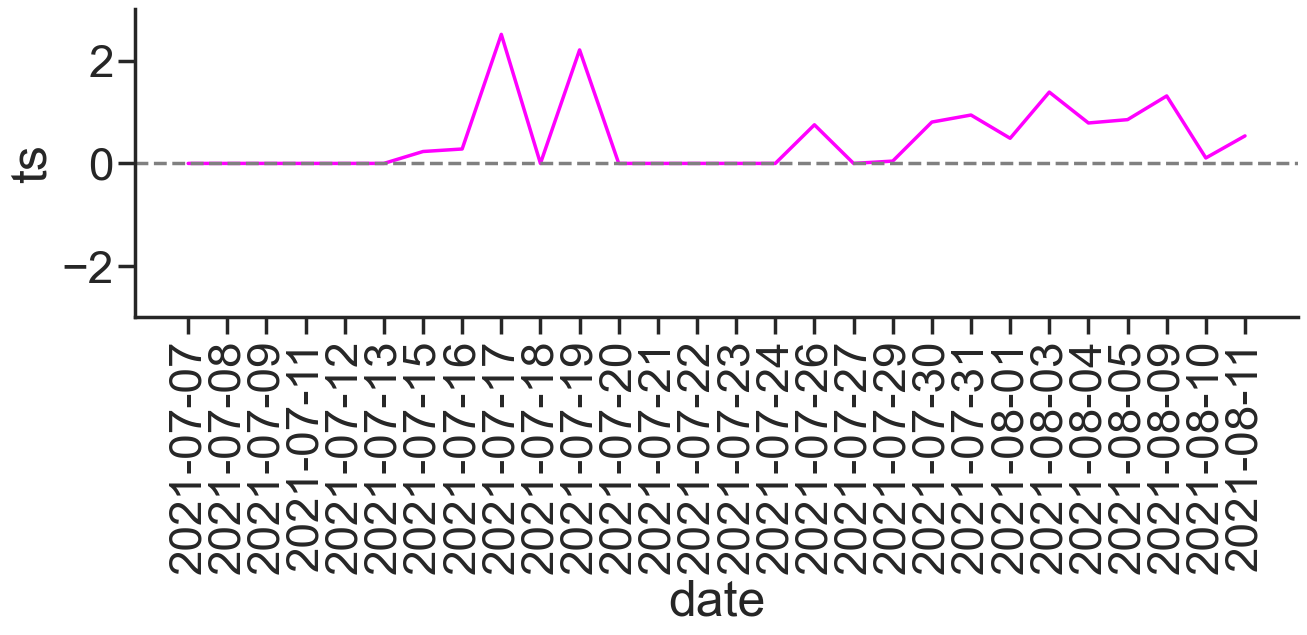

CC067431_HP2


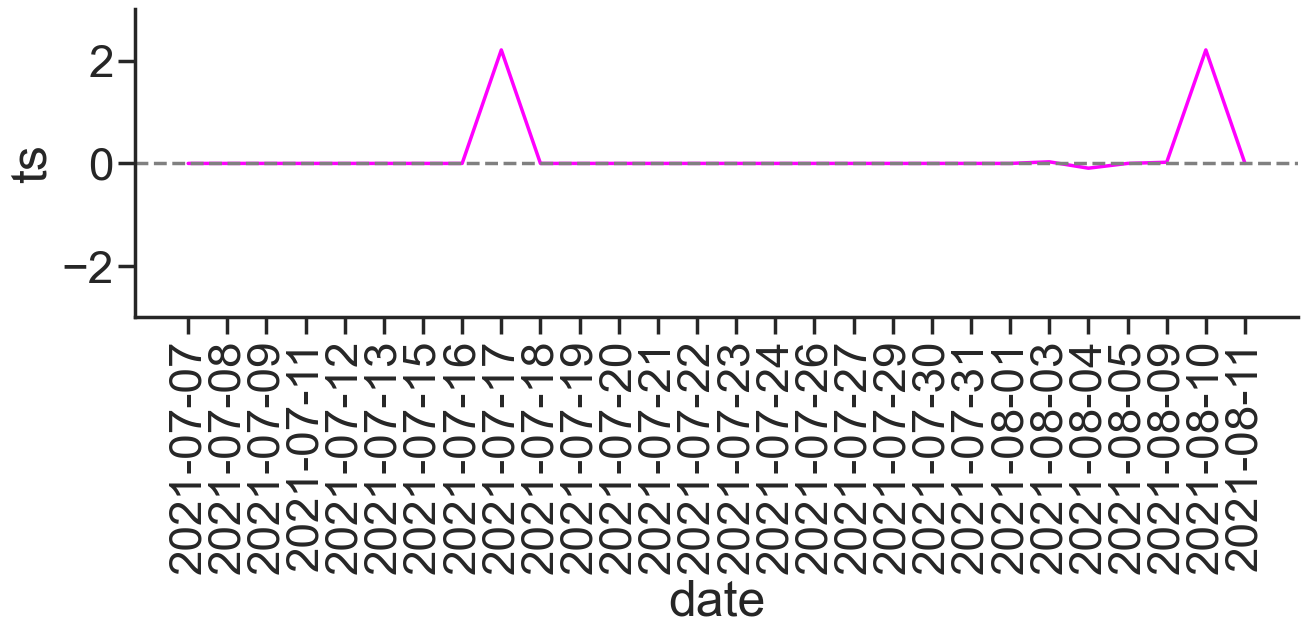

CC067431_HP3


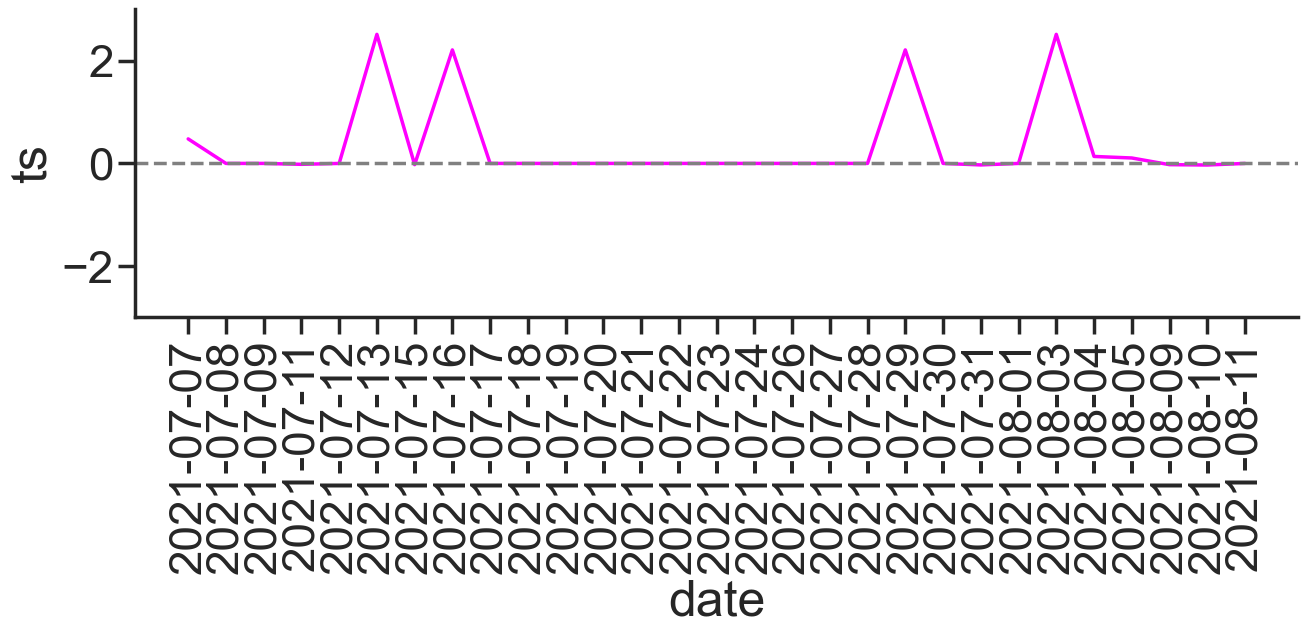

CC067432_HP1


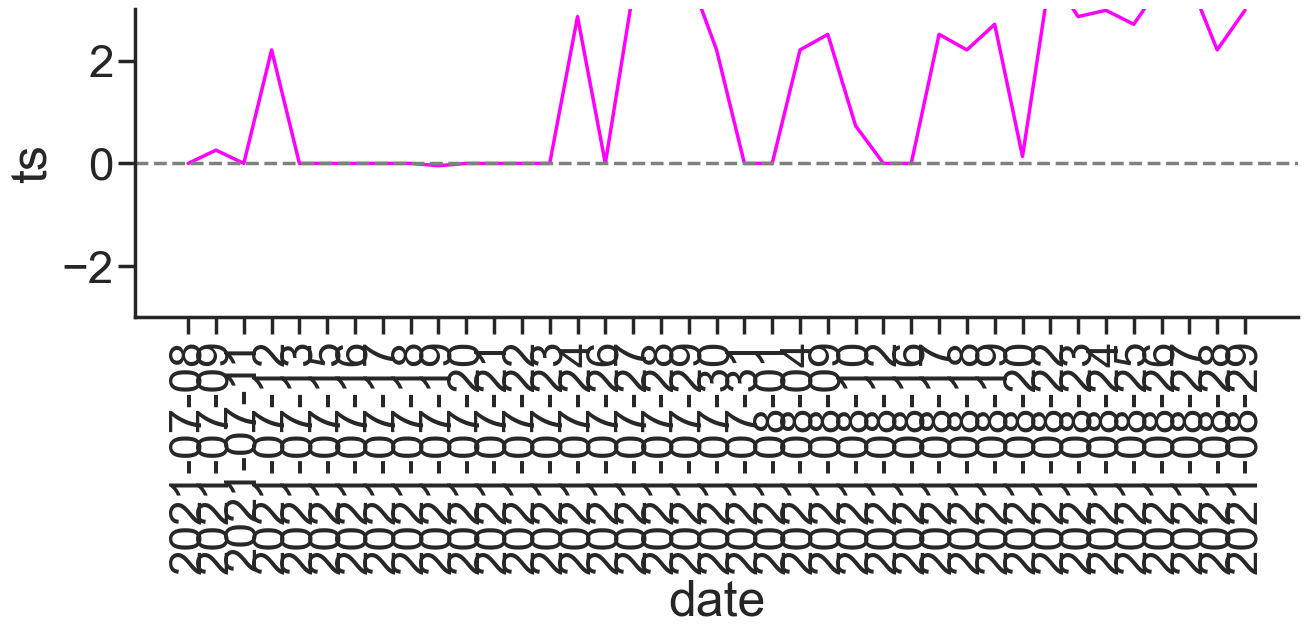

CC067432_HP2


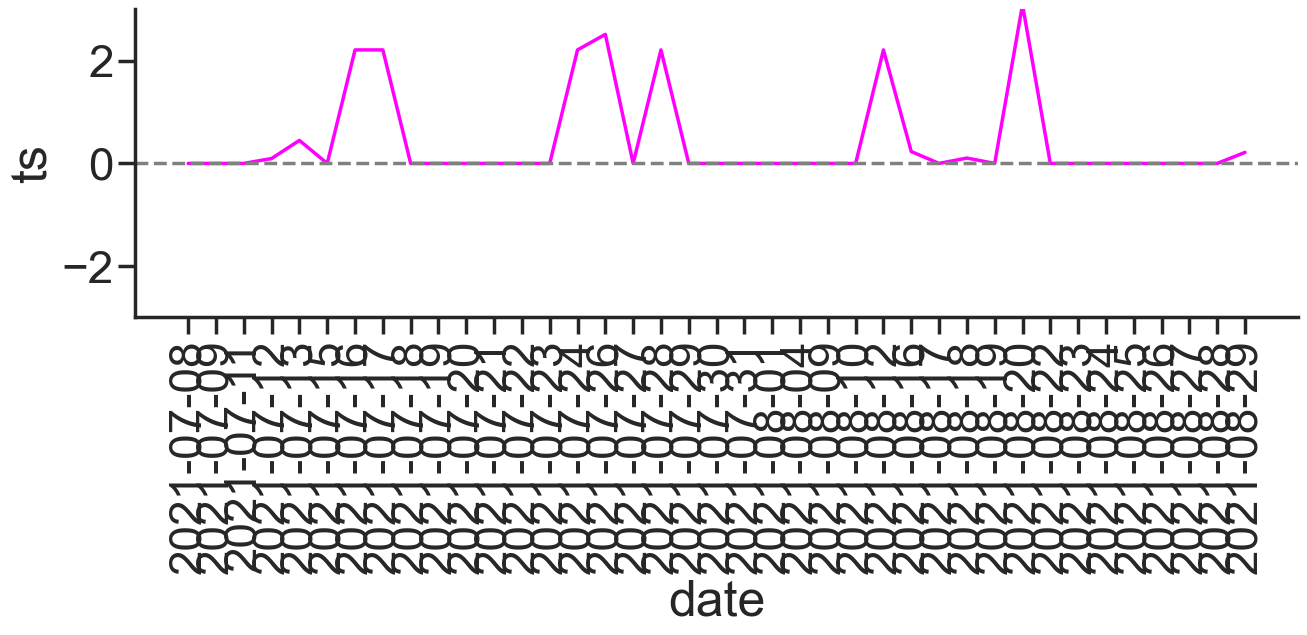

CC067432_HP3


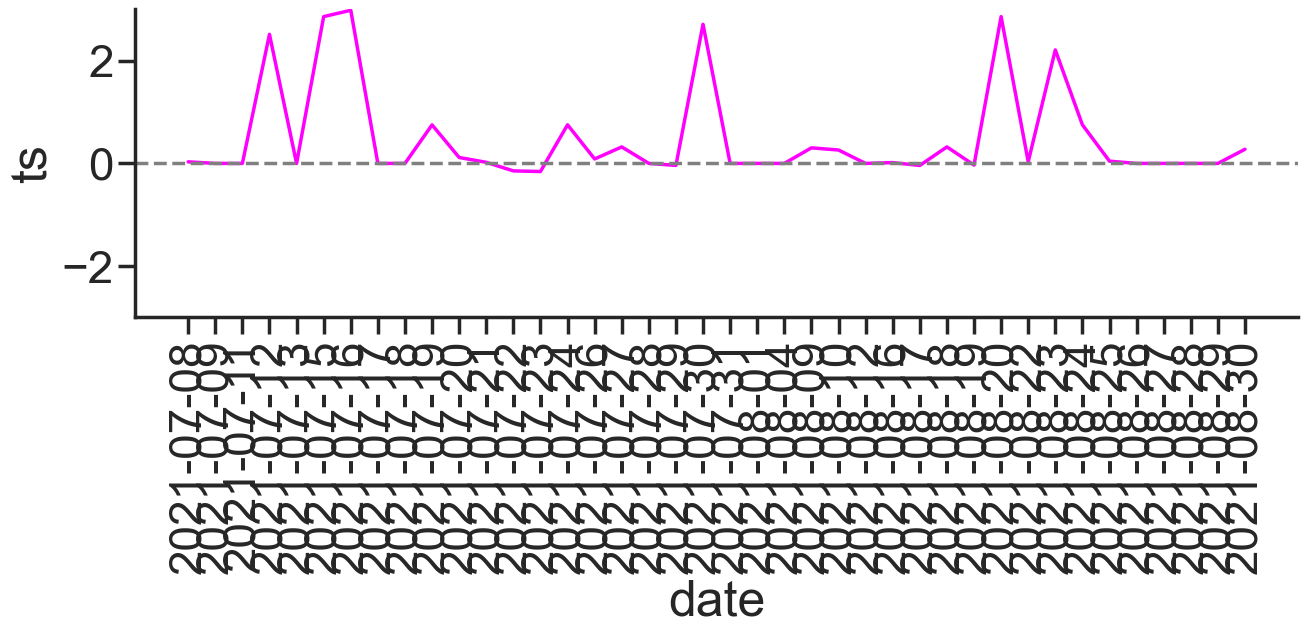

CC067432_HP4


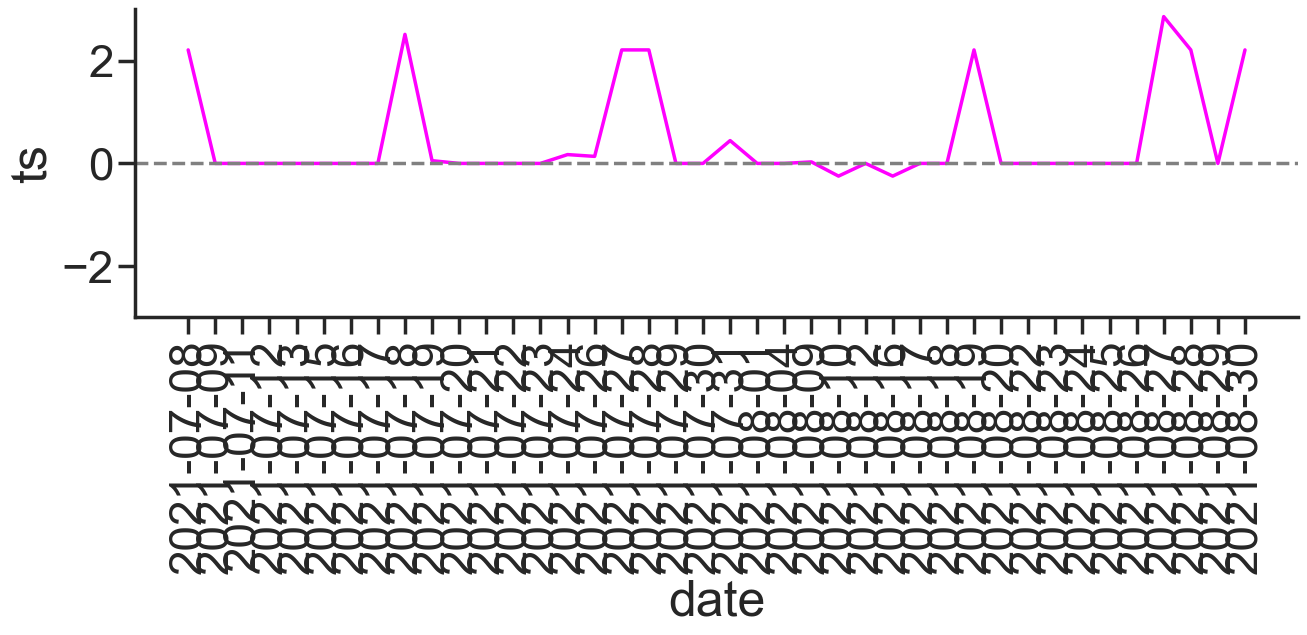

CC067489_HP1


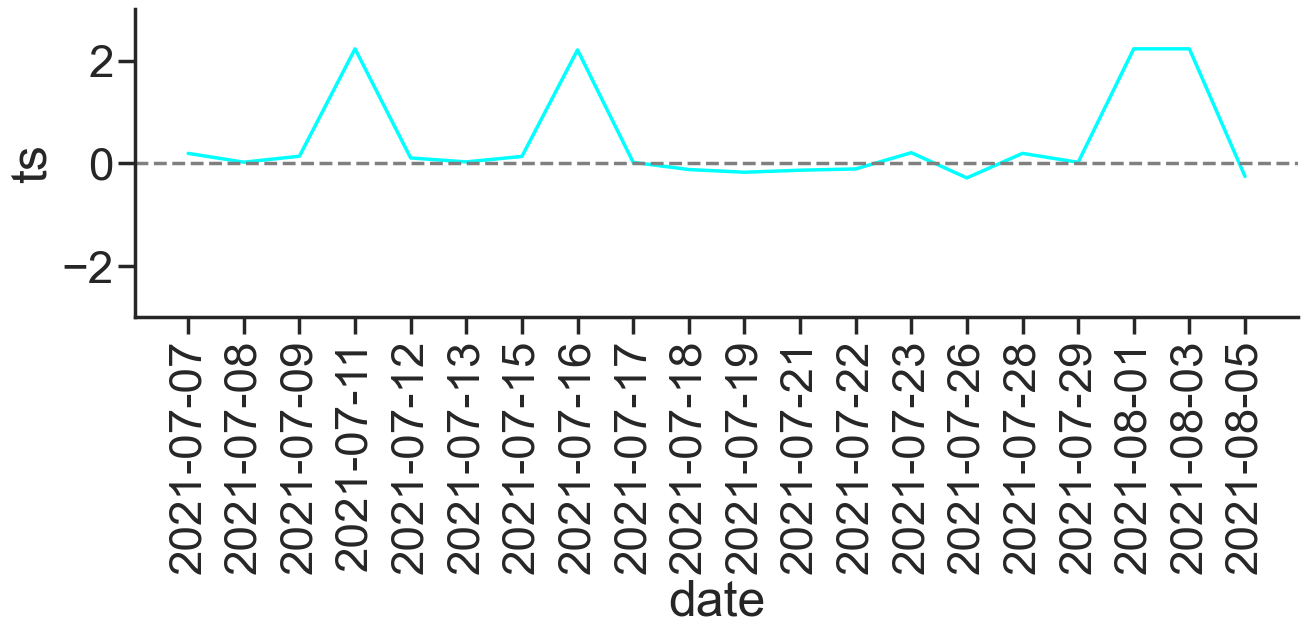

CC067489_HP2


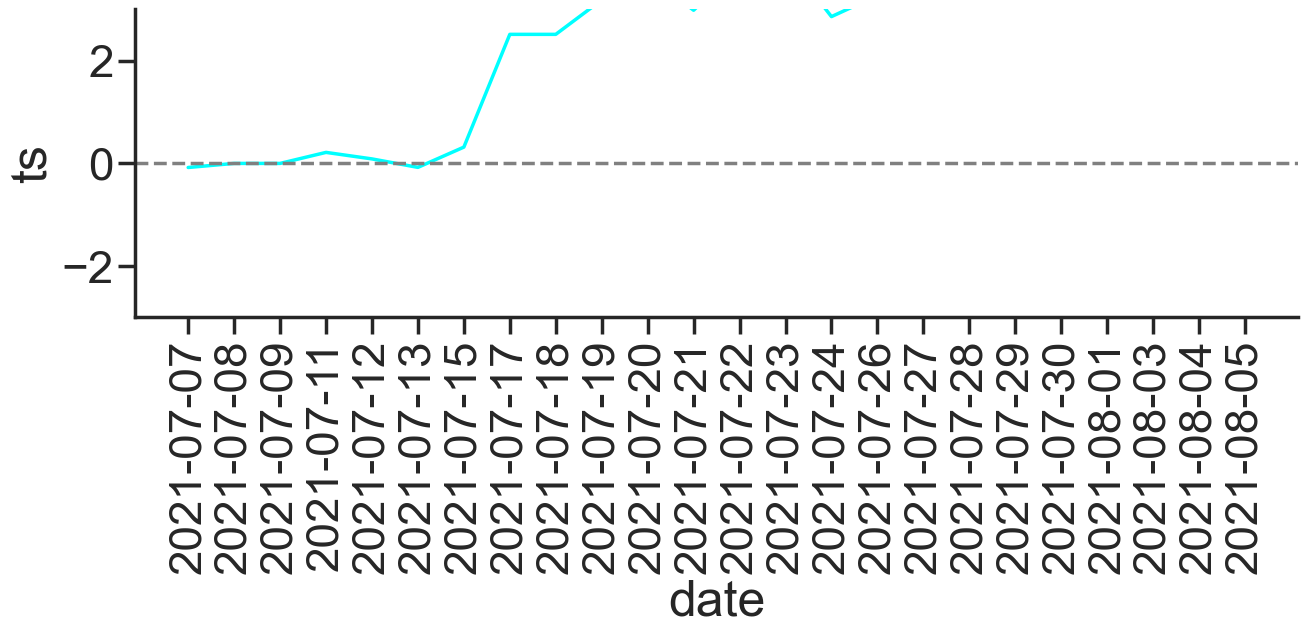

CC067489_HP3


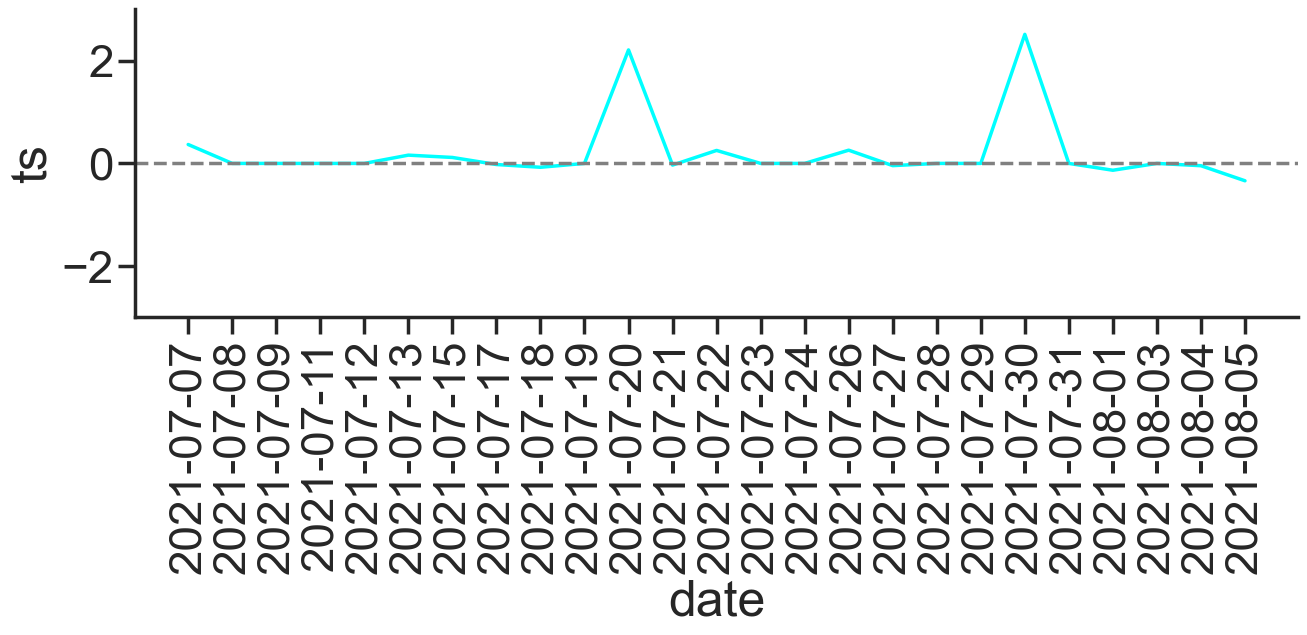

CC082255_HP0


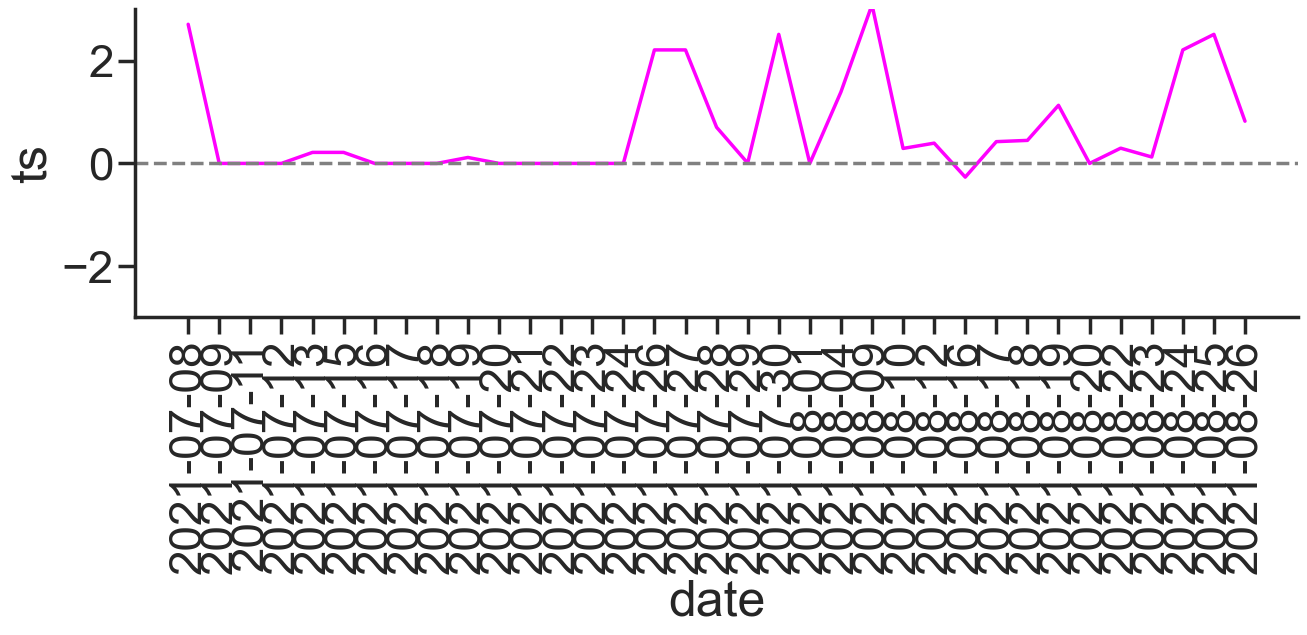

CC082255_HP3


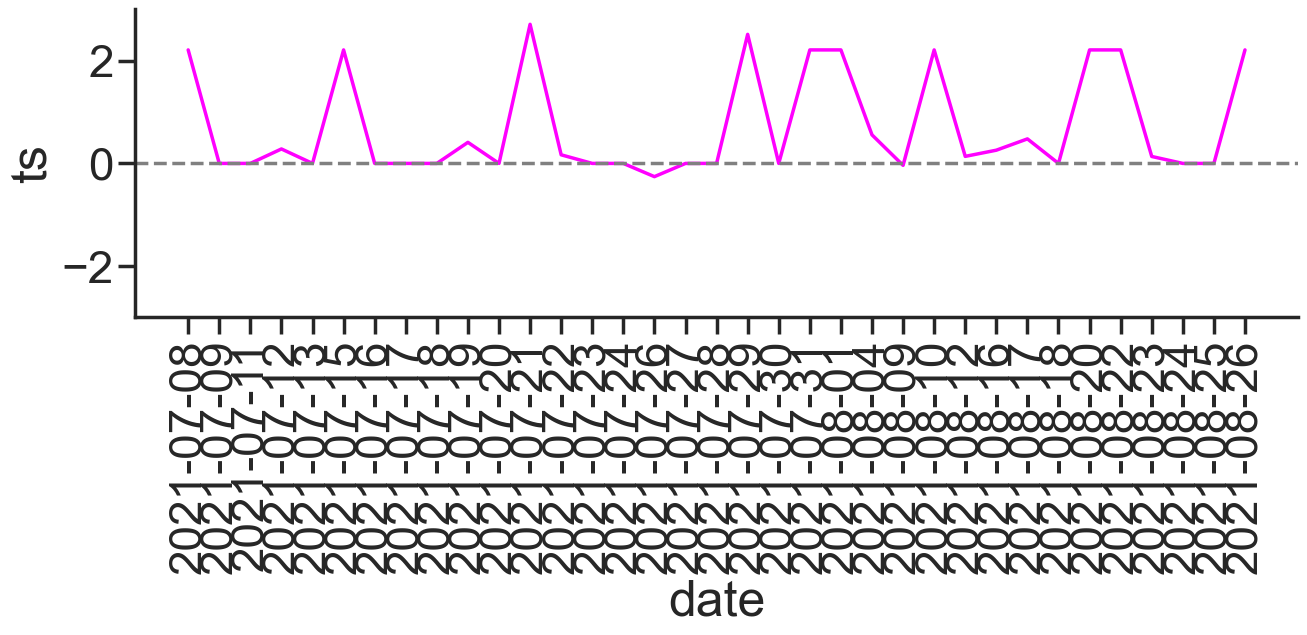

CC082256_HP3


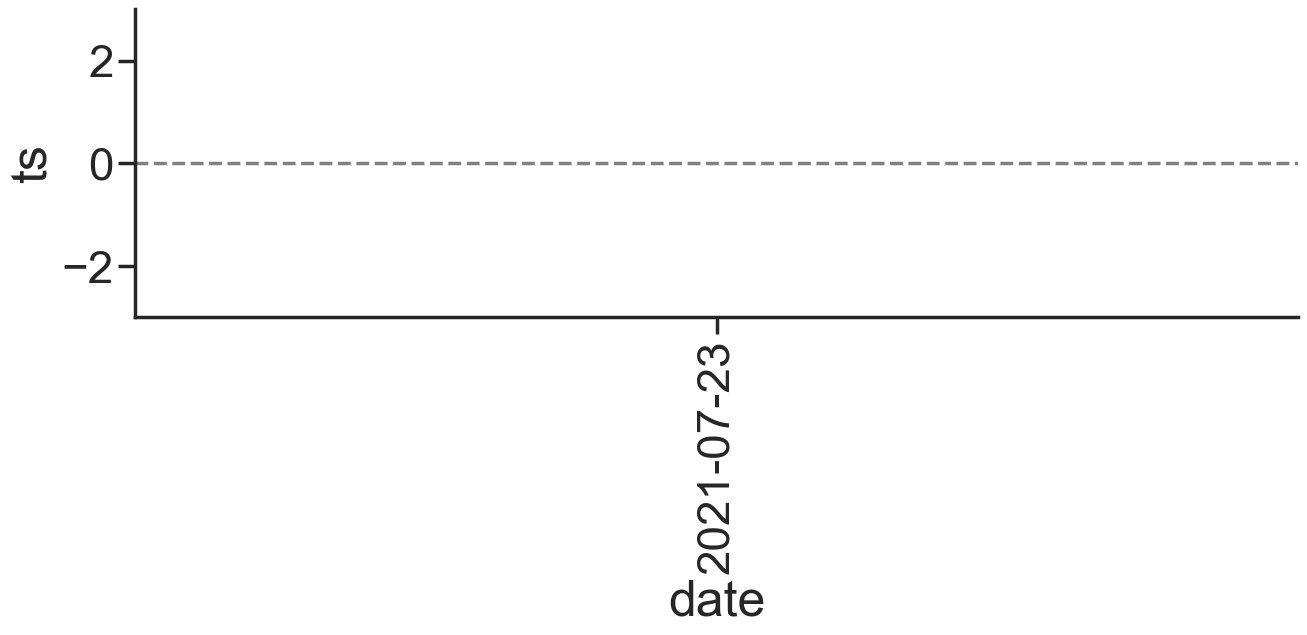

CC082257_HP1


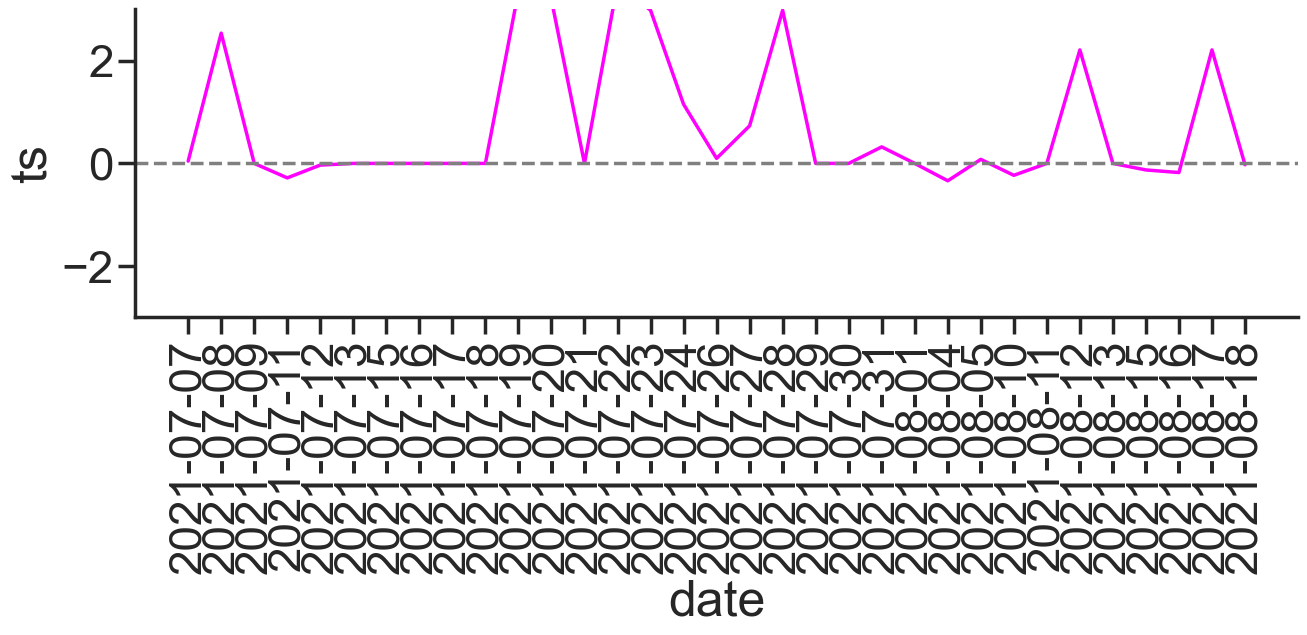

CC082257_HP2


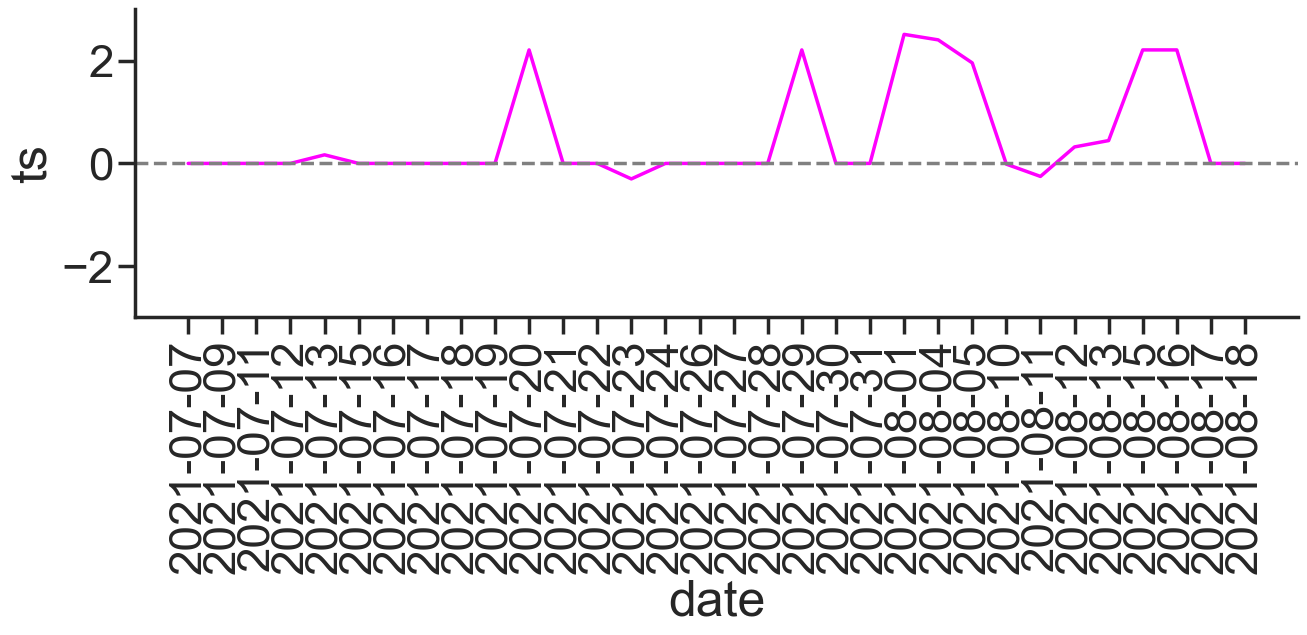

CC082257_HP3


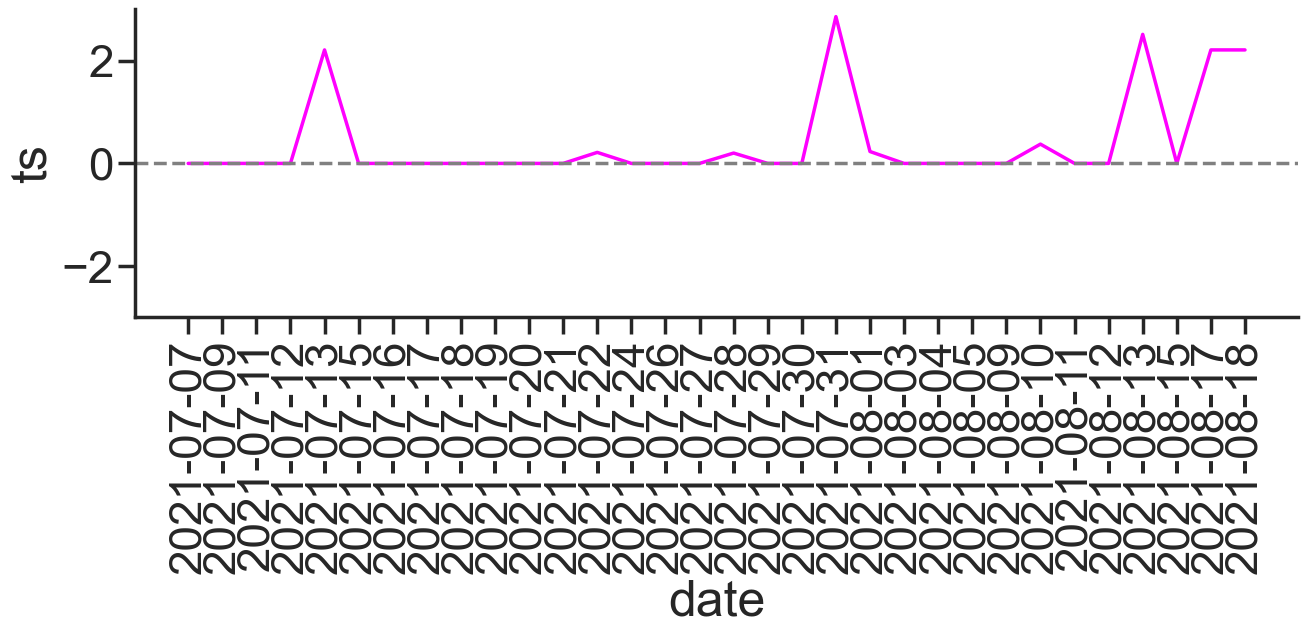

CC082260_HP1


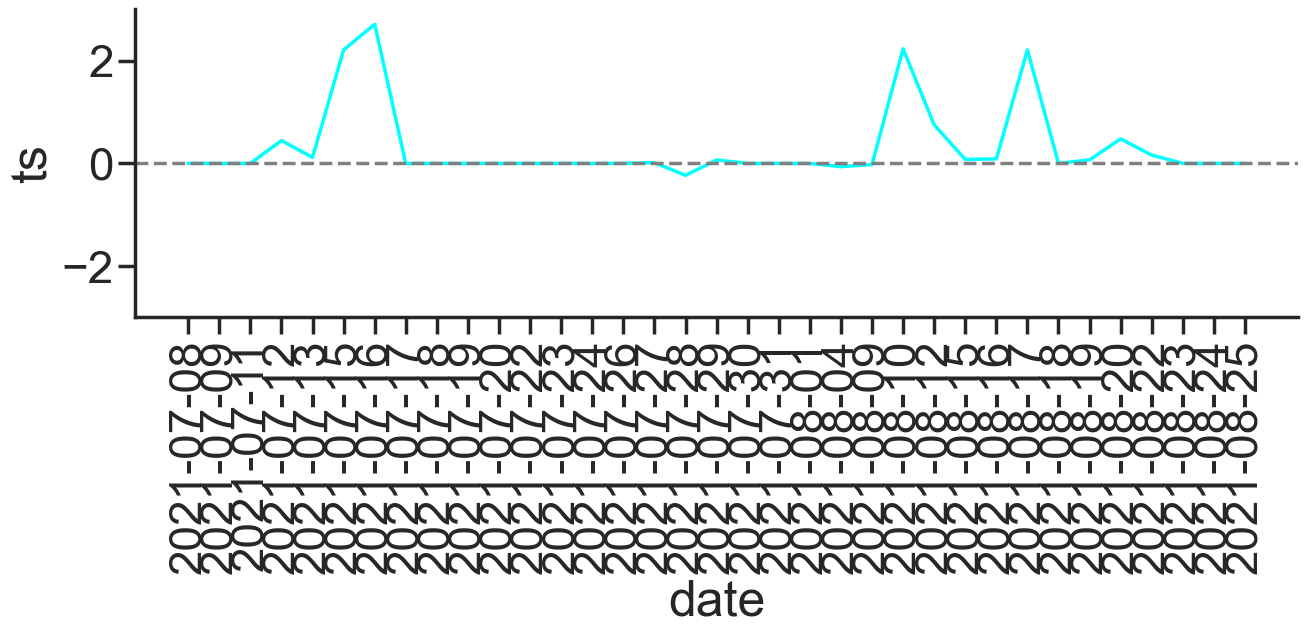

CC082260_HP2


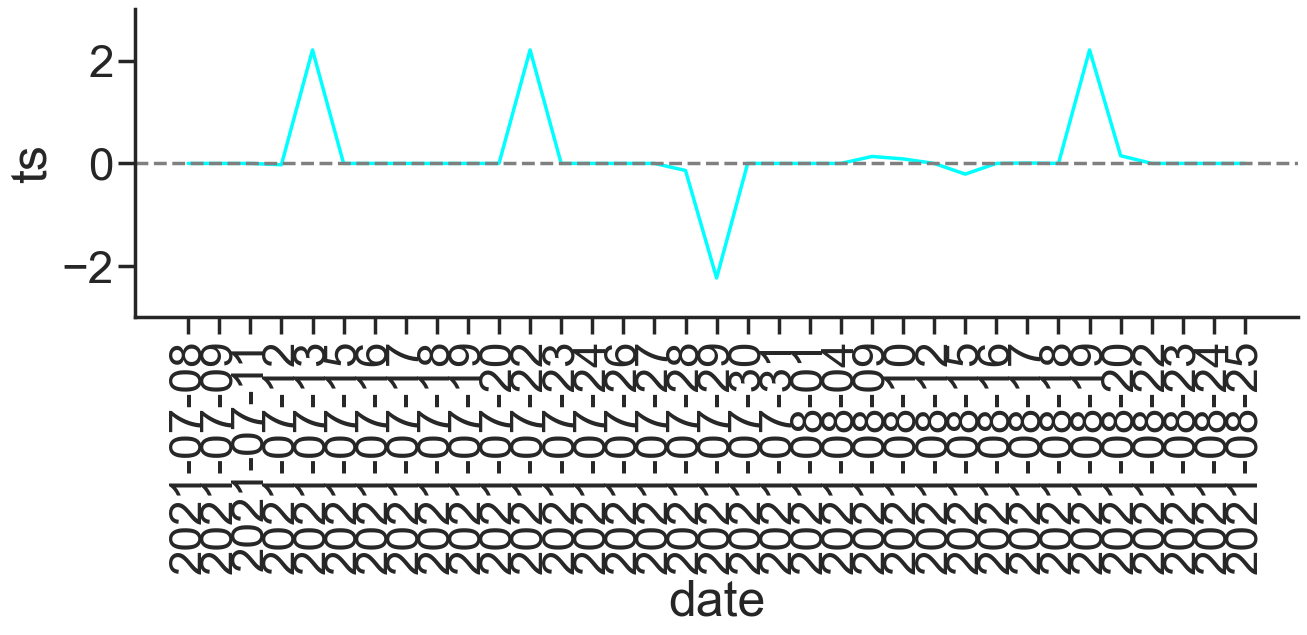

CC082260_HP3


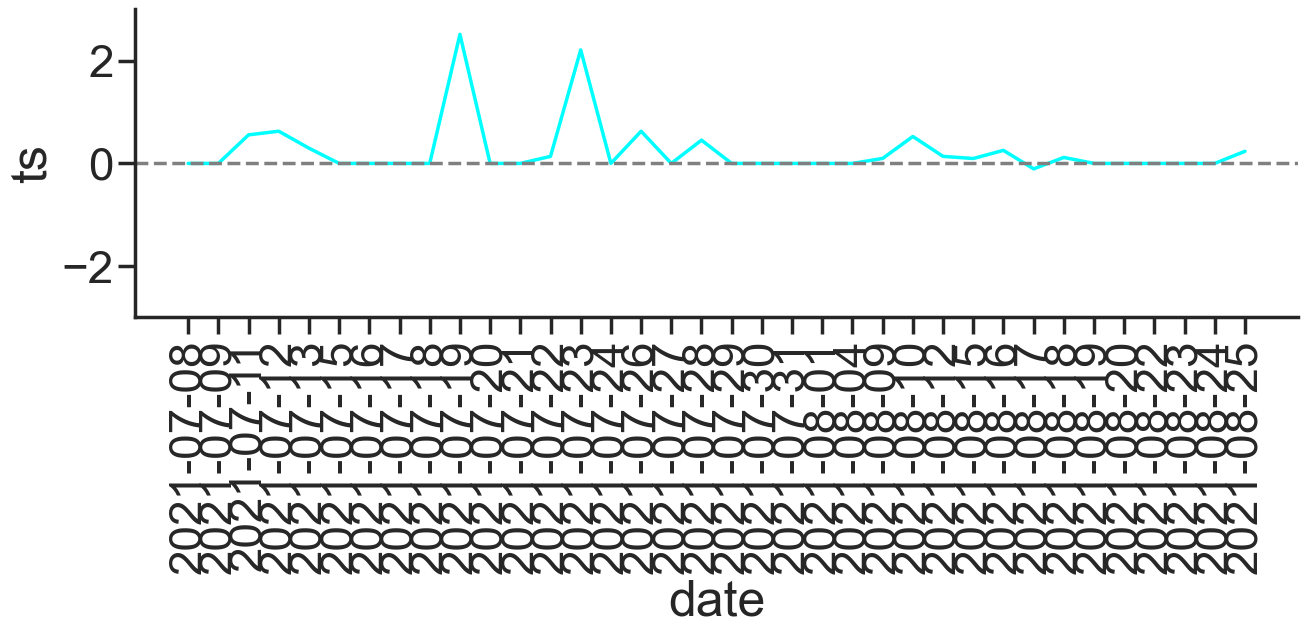

CC082260_HP4


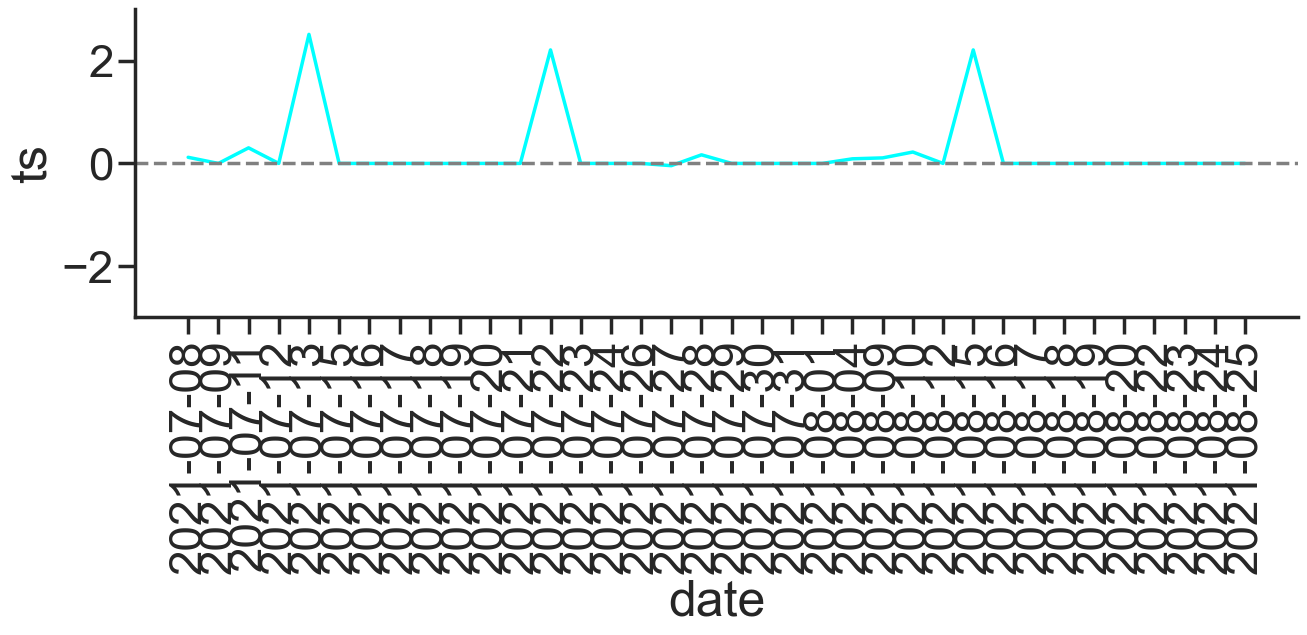

CC082263_HP1


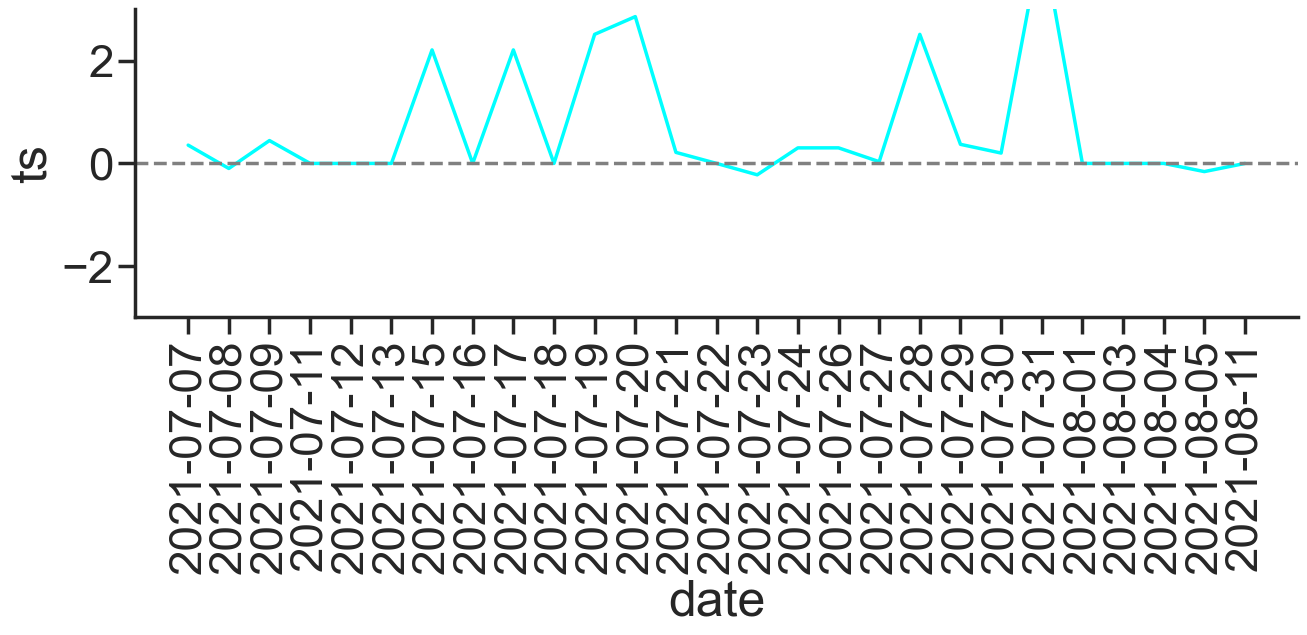

CC082263_HP2


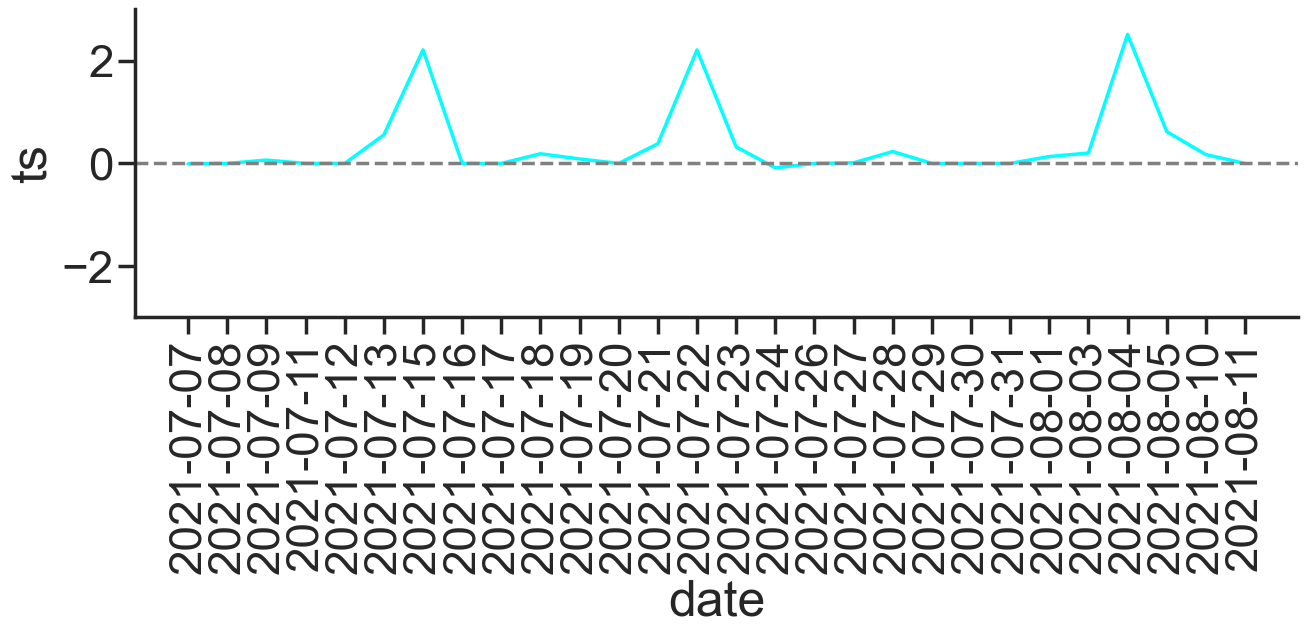

CC082263_HP3


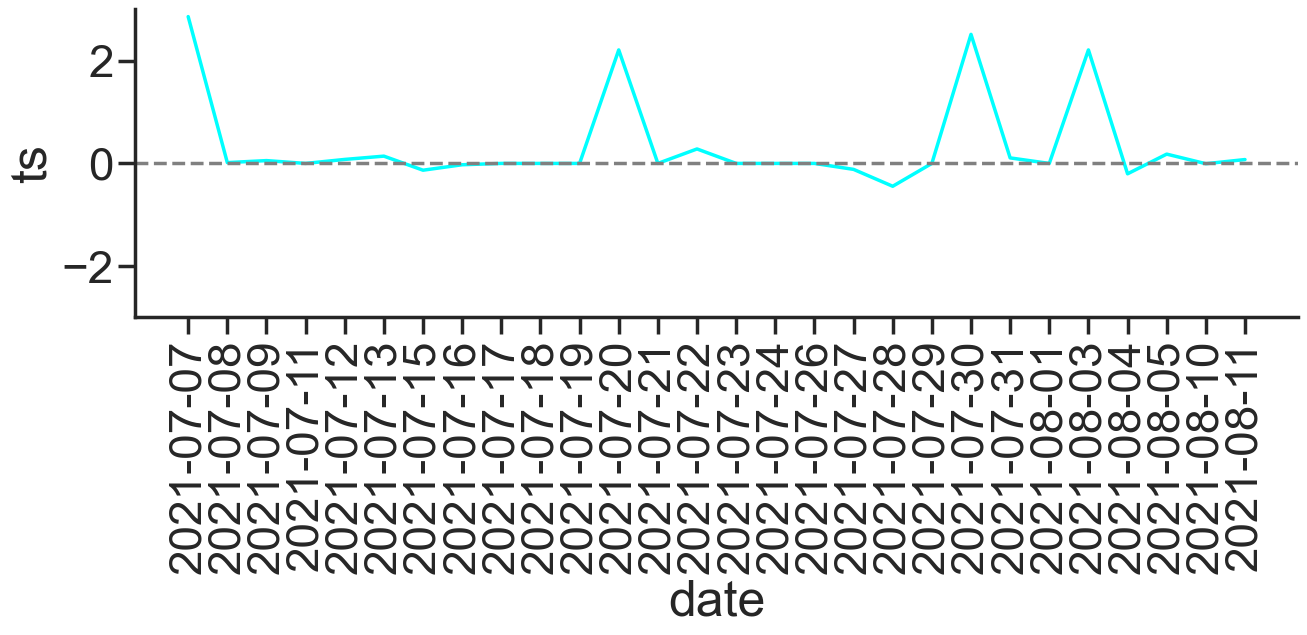

CC084521_HP1


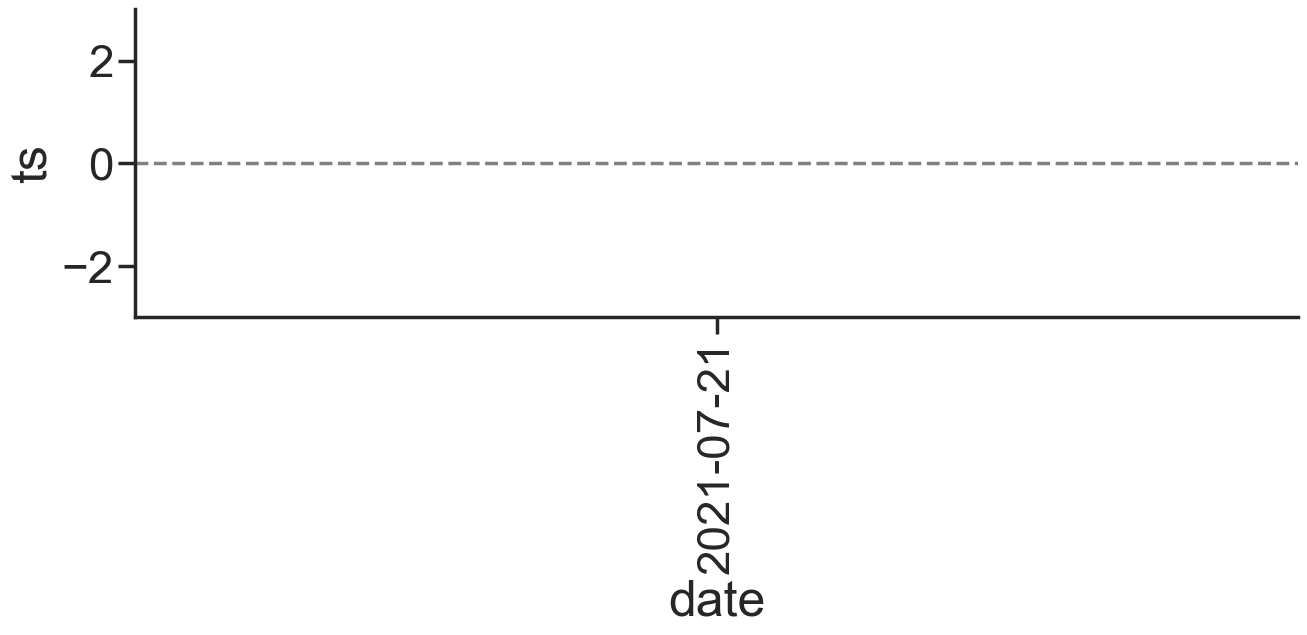

CC084621_HP1


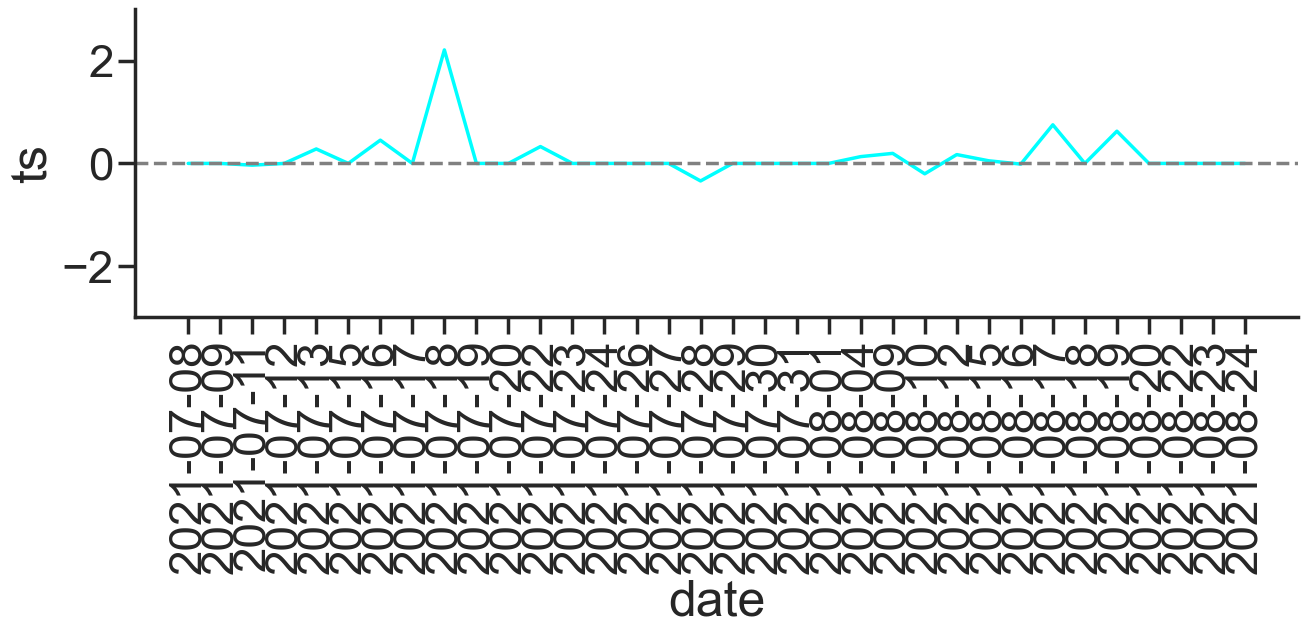

CC084621_HP2


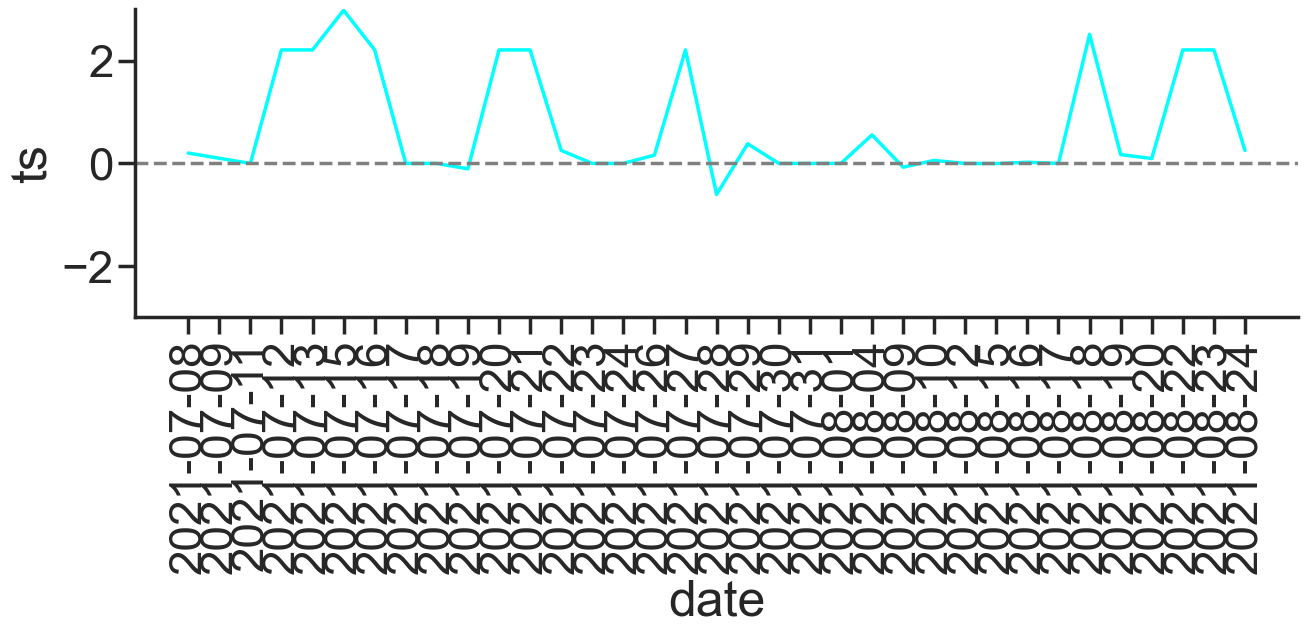

In [103]:
for m,mm in allDay_ts.groupby('et'):
    fig,ax = plt.subplots(1,1,figsize=(15,4), sharex=True, sharey=True)
    plt_color = 'cyan' if mm.group.unique()[0] == 'WT' else 'magenta'
    sns.lineplot(data=mm, x='date', y='ts', legend=False, color=plt_color, ax=ax)
    ax.set_ylim([-3,3])
    ax.axhline(0, ls='--', color='grey')
    plt.xticks(rotation=90)
    print(m)
    sns.despine()
    plt.show()

In [104]:
# rep_mice = ['CC067489_HP2', 'CC067432_HP1', 'CC067431_HP1', 'CC082255_HP0']
# plt_colors = ['cyan','cyan','magenta','magenta']

# for idx,mouse in enumerate(rep_mice):
#     solo_mouse = allDay_ts[allDay_ts.et == mouse]
#     fig,ax = plt.subplots(1,1,figsize=(15,4), sharex=True, sharey=True)
#     sns.lineplot(data=solo_mouse, x='day', y='ts', legend=False, color=plt_colors[idx], ax=ax)
#     ax.set_ylim([-3,3])
#     # ax.set_xlim([-1,36])
#     ax.axhline(0, ls='--', color='grey')
#     ax.set_xlabel('Training Day')
#     ax.set_ylabel("TS (d')")
#     sns.despine()
#     # Change the end of this next line with a new file name!!
#     # plt.savefig(rf"U:\Papers\FX Behavior paper\Figures\lick_behavior\Example_mouse{idx}_allDayTS.pdf", transparent=True)
#     plt.show()

In [105]:
start_wt = []
inter_wt = []
end_wt = []
start_fx = []
inter_fx = []
end_fx = []
for keyy in overall_dict:
    mouse_ts_values = overall_dict[keyy]
    ts_values = np.array(mouse_ts_values)
    # print(keyy, ts_values)
    cc = keyy.split('_')[0]

    if keyy in ['CC067431_HP2','CC067431_HP3','CC067489_HP3','CC082256_HP3','CC084521_HP1']:
        continue
    else:
        if (cc == 'CC082263') | (cc == 'CC067489') | (cc == 'CC082260') | (cc == 'CC084621'):
            start_wt.append(ts_values[0]) #start of training
            inter_wt.append(ts_values[5])
            end_wt.append(ts_values[-1])  #end of training
        elif (cc == 'CC082257') | (cc == 'CC067431') | (cc == 'CC067432') | (cc == 'CC082255'):
            start_fx.append(ts_values[0]) #start of training
            inter_fx.append(ts_values[5])
            end_fx.append(ts_values[1]) #end of training


In [106]:
startA_df = pd.DataFrame(tuple(zip(start_wt,(['WT']*len(start_wt)),(['start']*len(start_wt)))),
                         columns=['tscore','group','session'])
interA_df = pd.DataFrame(tuple(zip(inter_wt,(['WT']*len(inter_wt)),(['inter']*len(inter_wt)))),
                         columns=['tscore','group','session'])
endA_df = pd.DataFrame(tuple(zip(end_wt,(['WT']*len(end_wt)),(['end']*len(end_wt)))),
                         columns=['tscore','group','session'])

startB_df = pd.DataFrame(tuple(zip(start_fx,(['FX']*len(start_fx)),(['start']*len(start_fx)))),
                         columns=['tscore','group','session'])
interB_df = pd.DataFrame(tuple(zip(inter_fx,(['FX']*len(inter_fx)),(['inter']*len(inter_fx)))),
                         columns=['tscore','group','session'])
endB_df = pd.DataFrame(tuple(zip(end_fx,(['FX']*len(end_fx)),(['end']*len(end_fx)))),
                         columns=['tscore','group','session'])

all_ts = pd.concat([startA_df,interA_df,endA_df,startB_df,interB_df,endB_df])
all_ts.head()

,tscore,group,session
0,0.195671,WT,start
1,-0.079289,WT,start
2,0.356180,WT,start
3,-0.007953,WT,start
4,2.859819,WT,start


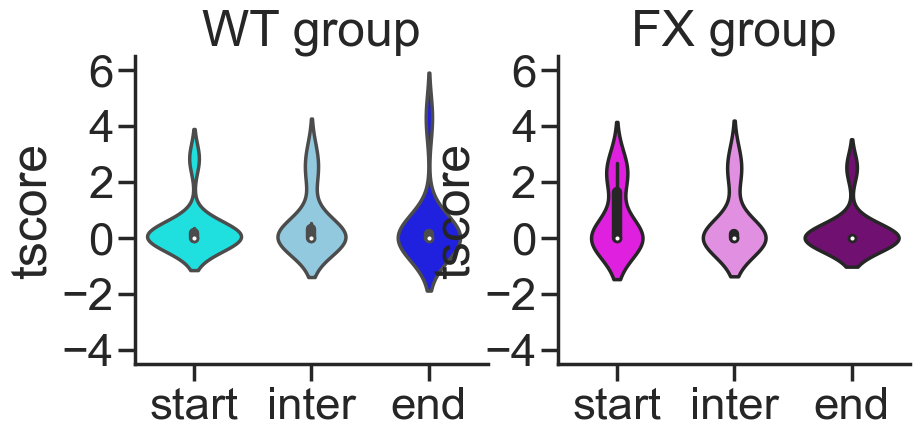

In [107]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 10.0 # x dimension
fig_size[1] = 4.0 # y dimension
plt.tight_layout()

ax1 = plt.subplot(121)
sns.violinplot(x="session", y="tscore", data=all_ts[all_ts['group'] == 'WT'],
               palette=['cyan','skyblue','blue'])
plt.ylim([-4.5,6.5])
plt.yticks(ticks=[-4,-2,0,2,4,6])
plt.title('WT group')
plt.xlabel('')

ax2 = plt.subplot(122, sharey=ax1)
sns.violinplot(x="session", y="tscore", data=all_ts[all_ts['group'] == 'FX'],
            palette=['magenta','violet','purple'])
plt.title('FX group')
plt.xlabel('')

sns.despine()
# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\violinplots.pdf", transparent=True)
plt.show()

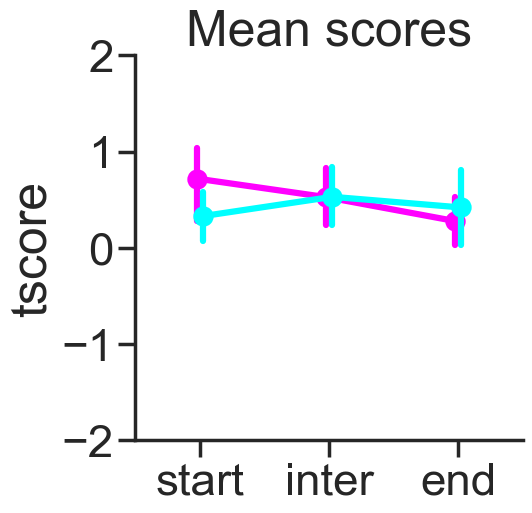

In [108]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 5.0 # x dimension
fig_size[1] = 5.0 # y dimension

sns.pointplot(x="session", y="tscore", hue='group', data=all_ts, 
              hue_order=['FX','WT'], palette=['magenta','cyan'],
              errorbar=('ci',68), dodge=True)

plt.ylim([-2,2])
plt.title('Mean scores')
plt.xlabel('')
plt.legend([],[],frameon=False)

sns.despine()
# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\licks\mean_line.pdf", transparent=True)
plt.show()

# run the stats for the box & whisker plots

In [109]:
data1 = all_ts[all_ts['group'] == 'WT']
data2 = all_ts[all_ts['group'] == 'FX']

varA1 = data1[data1['session']=='start'].tscore.values
varA2 = data1[data1['session']=='inter'].tscore.values
varA3 = data1[data1['session']=='end'].tscore.values

varB1 = data2[data2['session']=='start'].tscore.values
varB2 = data2[data2['session']=='inter'].tscore.values
varB3 = data2[data2['session']=='end'].tscore.values

print('WT training scores')
print('S-I: {0}'.format(sstat.ttest_ind(varA1, varA2)))
print('S-E: {0}'.format(sstat.ttest_ind(varA1, varA3)))
print('I-E: {0}'.format(sstat.ttest_ind(varA2, varA3)))
print('FX training scores')
print('S-I: {0}'.format(sstat.ttest_ind(varB1, varB2)))
print('S-E: {0}'.format(sstat.ttest_ind(varB1, varB3)))
print('I-E: {0}'.format(sstat.ttest_ind(varB2, varB3)))

WT training scores
S-I: TtestResult(statistic=-0.49129999387494366, pvalue=0.6285624316007681, df=20.0)
S-E: TtestResult(statistic=-0.1906890033426126, pvalue=0.8506916090678235, df=20.0)
I-E: TtestResult(statistic=0.21997566553577783, pvalue=0.8281198622385085, df=20.0)
FX training scores
S-I: TtestResult(statistic=0.3867002931480602, pvalue=0.7035115739563815, df=18.0)
S-E: TtestResult(statistic=0.9959997605602, pvalue=0.3324520305834382, df=18.0)
I-E: TtestResult(statistic=0.5894192679249713, pvalue=0.5629057819458994, df=18.0)


# run stats for the mean change between groups

In [99]:
data1 = all_ts[all_ts['session'] == 'start']
data2 = all_ts[all_ts['session'] == 'inter']
data3 = all_ts[all_ts['session'] == 'end']

print('Mean training scores (WT vs FX)')
print('1: {0}'.format(sstat.ttest_ind(data1[data1['group'] == 'WT'].tscore.values, 
                                      data1[data1['group'] == 'FX'].tscore.values)))
print('2: {0}'.format(sstat.ttest_ind(data2[data2['group'] == 'WT'].tscore.values, 
                                      data2[data2['group'] == 'FX'].tscore.values)))
print('3: {0}'.format(sstat.ttest_ind(data3[data3['group'] == 'WT'].tscore.values, 
                                      data3[data3['group'] == 'FX'].tscore.values)))

Mean training scores (WT vs FX)
1: TtestResult(statistic=-0.7686146575469367, pvalue=0.45157085872140645, df=19.0)
2: TtestResult(statistic=-0.08523809034745887, pvalue=0.9329638951870227, df=19.0)
3: TtestResult(statistic=0.6447201075380598, pvalue=0.5268170164537184, df=19.0)
